:이 배우가 나오면 대박일까 쪽박일까?,
로지스틱 회귀, 지도-분류

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (30.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

✅ 업로드된 파일에서 데이터 로딩 완료!

🤖 AI 예측 정확도: 82.0%

--- 🎬 가상 캐스팅: 500만 돌파 확률 ---
👉 [최민식] 주연 발탁 시 500만 돌파 확률: 13.0%
👉 [이병헌] 주연 발탁 시 500만 돌파 확률: 21.7%
👉 [강하늘] 주연 발탁 시 500만 돌파 확률: 8.1%
👉 [공유] 주연 발탁 시 500만 돌파 확률: 12.3%
👉 [이정재] 주연 발탁 시 500만 돌파 확률: 29.6%
👉 [정우성] 주연 발탁 시 500만 돌파 확률: 14.1%
👉 [송강호] 주연 발탁 시 500만 돌파 확률: 30.0%
👉 [김윤석] 주연 발탁 시 500만 돌파 확률: 22.1%


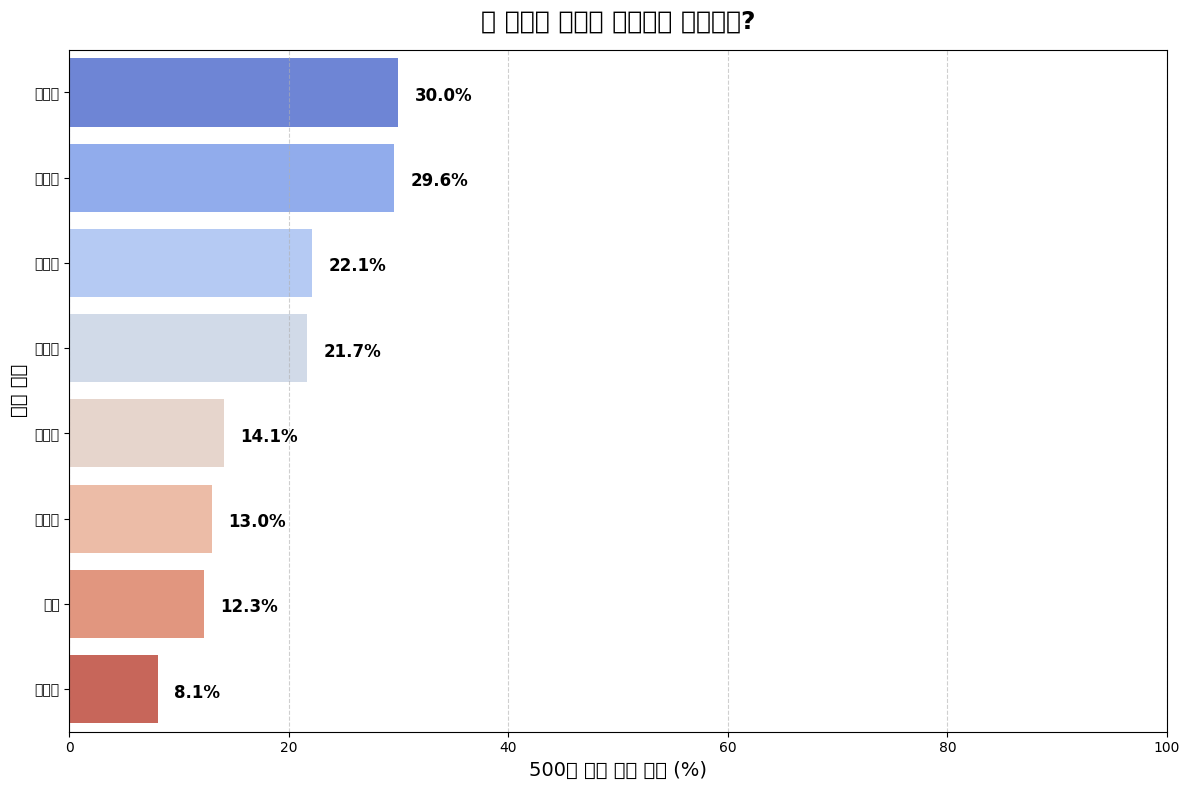

In [3]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

sys_font = fm.findSystemFonts()
nanum_font = [f for f in sys_font if 'Nanum' in f]
if nanum_font:
    font_name = fm.FontProperties(fname=nanum_font[0]).get_name()
    plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

file_path = 'top50_actors_boxoffice.csv'
df = pd.read_csv(file_path)
print(f"✅ 업로드된 파일에서 데이터 로딩 완료!\n")

df_clean = df[df['Audience'] > 0].copy()
df_clean['Actor'] = df_clean['Actor'].astype(str).str.strip()
threshold = 5000000
df_clean['Hit'] = (df_clean['Audience'] >= threshold).astype(int)

X = pd.get_dummies(df_clean[['Actor']])
y = df_clean['Hit']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"🤖 AI 예측 정확도: {accuracy_score(y_test, predictions) * 100:.1f}%\n")

print("--- 🎬 가상 캐스팅: 500만 돌파 확률 ---")

actors_encoded = X.columns
test_actors = [
    'Actor_최민식', 'Actor_이병헌', 'Actor_강하늘', 'Actor_공유',
    'Actor_이정재', 'Actor_정우성', 'Actor_송강호', 'Actor_김윤석'
]

names_list = []
probs_list = []

for actor_name in test_actors:
    if actor_name in actors_encoded:
        virtual_movie = pd.DataFrame(np.zeros((1, len(actors_encoded))), columns=actors_encoded)
        virtual_movie.at[0, actor_name] = 1

        success_prob = model.predict_proba(virtual_movie)[0][1] * 100
        clean_name = actor_name.replace('Actor_', '')

        names_list.append(clean_name)
        probs_list.append(success_prob)

        print(f"👉 [{clean_name}] 주연 발탁 시 500만 돌파 확률: {success_prob:.1f}%")

if probs_list:
    plt.figure(figsize=(12, 8))

    sorted_indices = np.argsort(probs_list)[::-1]
    sorted_probs = [probs_list[i] for i in sorted_indices]
    sorted_names = [names_list[i] for i in sorted_indices]

    sns.barplot(x=sorted_probs, y=sorted_names, palette='coolwarm')

    plt.title('이 배우가 나오면 대박일까 쪽박일까?', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('500만 흥행 돌파 확률 (%)', fontsize=14)
    plt.ylabel('배우 이름', fontsize=14)
    plt.xlim(0, 100)

    for index, value in enumerate(sorted_probs):
        plt.text(value + 1.5, index + 0.1, f"{value:.1f}%", fontsize=12, fontweight='bold')

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("선택하신 배우가 데이터에 없습니다. 파일 이름이나 배우 이름을 확인해주세요!")